Load Dataset

In [5]:
import pandas as pd
import numpy as np
df = pd.read_csv('cleaned_heart.csv')

Import ML Libraries

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
import joblib

In [8]:
# Drop derived columns (AgeGroup, BP_Category) — avoid data leakage
df_model = df.drop(columns=['AgeGroup', 'BP_Category'])

# Label encode all categorical columns
cat_features = ['Gender', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
le = LabelEncoder()

for col in cat_features:
    df_model[col] = le.fit_transform(df_model[col])
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

df_model.head()

Gender: {'F': np.int64(0), 'M': np.int64(1)}
ChestPainType: {'ASY': np.int64(0), 'ATA': np.int64(1), 'NAP': np.int64(2), 'TA': np.int64(3)}
RestingECG: {'LVH': np.int64(0), 'NORMAL': np.int64(1), 'ST': np.int64(2)}
ExerciseAngina: {'N': np.int64(0), 'Y': np.int64(1)}
ST_Slope: {'DOWN': np.int64(0), 'FLAT': np.int64(1), 'UP': np.int64(2)}


,Age,Gender,ChestPainType,RestingBloodPressure,Cholesterol,FastingBloodSugar,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,1,140.0,289.0,0,1,172,0,0.0,2,0
1,49,0,2,160.0,180.0,0,1,156,0,1.0,1,1
2,37,1,1,130.0,283.0,0,2,98,0,0.0,2,0
3,48,0,0,138.0,214.0,0,1,108,1,1.5,1,1
4,54,1,2,150.0,195.0,0,1,122,0,0.0,2,0


Train and Test Split

In [9]:
X = df_model.drop(columns=['HeartDisease'])
y = df_model['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")
print(f"Train balance: {y_train.value_counts().to_dict()}")
print(f"Test  balance: {y_test.value_counts().to_dict()}")

Train: 734 | Test: 184
Train balance: {1: 406, 0: 328}
Test  balance: {1: 102, 0: 82}


Train All Models

In [10]:
models = {
    'Logistic Regression' : Pipeline([('scaler', StandardScaler()),
                                       ('clf', LogisticRegression(max_iter=500, random_state=42))]),
    'Random Forest'       : RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=200, random_state=42),
    'XGBoost'             : XGBClassifier(n_estimators=200, eval_metric='logloss',
                                          random_state=42, use_label_encoder=False),
    'SVM'                 : Pipeline([('scaler', StandardScaler()),
                                      ('clf', SVC(probability=True, random_state=42))])
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print(f"{'Model':<25} {'CV Acc':>8} {'Test Acc':>10} {'ROC-AUC':>9}")
print('-' * 58)

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=skf, scoring='accuracy')
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    acc     = accuracy_score(y_test, y_pred)
    auc     = roc_auc_score(y_test, y_proba)

    results[name] = {'model': model, 'cv_mean': cv_scores.mean(),
                     'test_acc': acc, 'roc_auc': auc,
                     'y_pred': y_pred, 'y_proba': y_proba}

    print(f"{name:<25} {cv_scores.mean():.4f}   {acc:.4f}    {auc:.4f}")

Model                       CV Acc   Test Acc   ROC-AUC
----------------------------------------------------------
Logistic Regression       0.8379   0.8478    0.8989
Random Forest             0.8529   0.8750    0.9274
Gradient Boosting         0.8584   0.8478    0.9120


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:58:57] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:58:57] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:58:57] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:58:57] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

XGBoost                   0.8502   0.8424    0.9118
SVM                       0.8570   0.8587    0.9199


Compare all Models

              Model  CV Accuracy  Test Accuracy  ROC-AUC
      Random Forest       0.8529         0.8750   0.9274
                SVM       0.8570         0.8587   0.9199
  Gradient Boosting       0.8584         0.8478   0.9120
            XGBoost       0.8502         0.8424   0.9118
Logistic Regression       0.8379         0.8478   0.8989


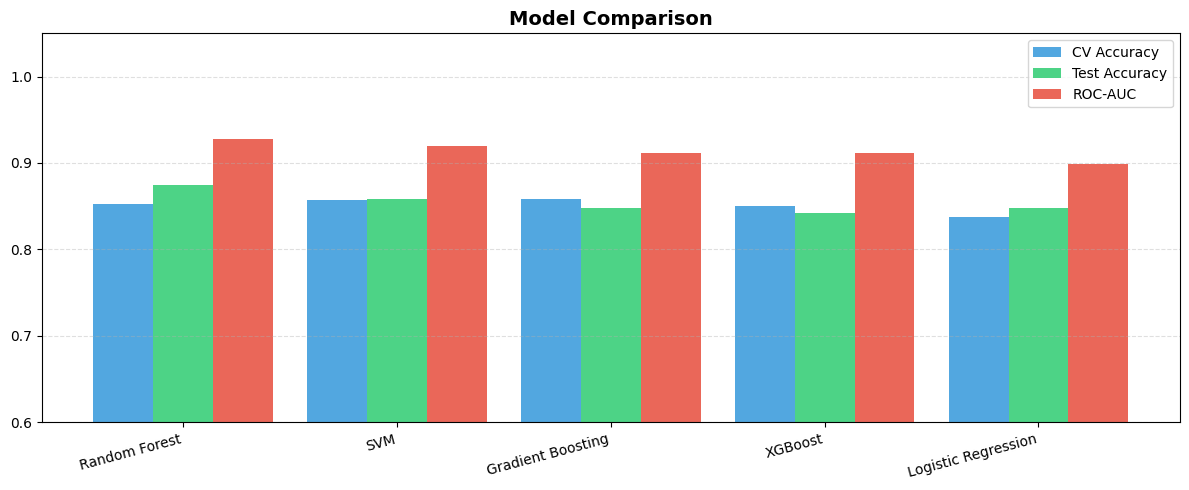

In [11]:
import numpy as np

summary = pd.DataFrame({
    'Model'        : list(results.keys()),
    'CV Accuracy'  : [results[m]['cv_mean']  for m in results],
    'Test Accuracy': [results[m]['test_acc'] for m in results],
    'ROC-AUC'      : [results[m]['roc_auc']  for m in results]
}).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

print(summary.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(summary))
w = 0.28
ax.bar(x-w, summary['CV Accuracy'],   w, label='CV Accuracy',   color='#3498db', alpha=0.85)
ax.bar(x,   summary['Test Accuracy'], w, label='Test Accuracy', color='#2ecc71', alpha=0.85)
ax.bar(x+w, summary['ROC-AUC'],       w, label='ROC-AUC',       color='#e74c3c', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(summary['Model'], rotation=15, ha='right')
ax.set_ylim(0.6, 1.05)
ax.set_title('Model Comparison', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

Best Model Report

In [12]:
best_name  = summary.iloc[0]['Model']
best_res   = results[best_name]
best_model = best_res['model']

print(f"🏆 Best Model : {best_name}")
print(f"   Test Acc   : {best_res['test_acc']:.4f}")
print(f"   ROC-AUC    : {best_res['roc_auc']:.4f}\n")

print(classification_report(y_test, best_res['y_pred'],
                             target_names=['No Disease', 'Heart Disease']))

🏆 Best Model : Random Forest
   Test Acc   : 0.8750
   ROC-AUC    : 0.9274

               precision    recall  f1-score   support

   No Disease       0.87      0.84      0.86        82
Heart Disease       0.88      0.90      0.89       102

     accuracy                           0.88       184
    macro avg       0.87      0.87      0.87       184
 weighted avg       0.87      0.88      0.87       184



Confusion Matrix + ROC Curve

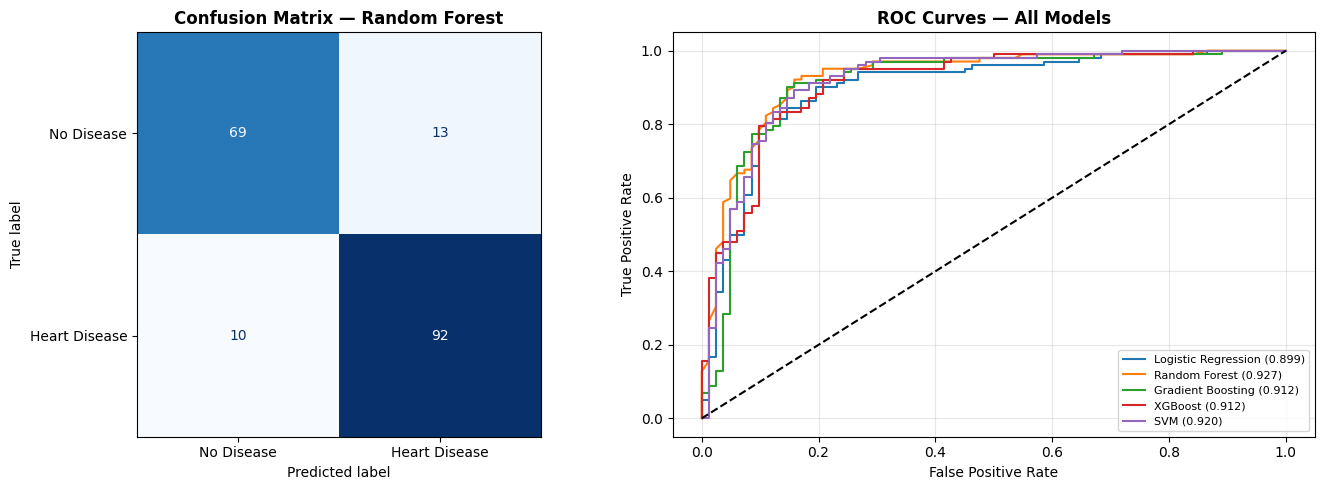

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, best_res['y_pred'])
ConfusionMatrixDisplay(cm, display_labels=['No Disease','Heart Disease']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Confusion Matrix — {best_name}', fontweight='bold')

for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    axes[1].plot(fpr, tpr, label=f"{name} ({res['roc_auc']:.3f})")

axes[1].plot([0,1],[0,1],'k--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves — All Models', fontweight='bold')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

Feature Importance

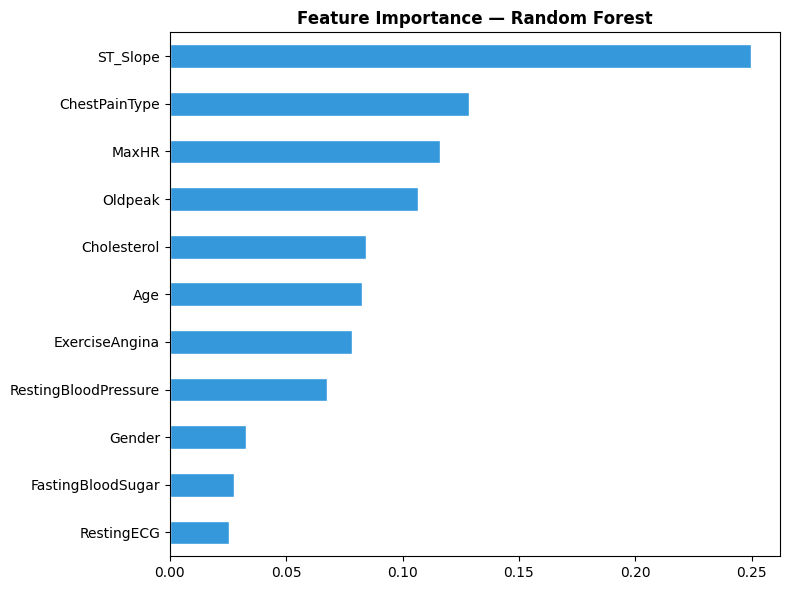

In [18]:
feature_names = X.columns.tolist()

try:
    if hasattr(best_model, 'feature_importances_'):
        importances = best_model.feature_importances_
    else:
        importances = np.abs(best_model.named_steps['clf'].coef_[0])

    feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=True)
    plt.figure(figsize=(8, 6))
    feat_imp.plot(kind='barh', color='#3498db', edgecolor='white')
    plt.title(f'Feature Importance — {best_name}', fontweight='bold')
    plt.tight_layout()
    plt.show()
except:
    print(f"ℹ️  Not available for {best_name}")

 Save Model

In [19]:
joblib.dump(best_model, 'heart_failure_model.pkl')
print("✅ Model saved!")

from google.colab import files
files.download('heart_failure_model.pkl')

✅ Model saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

example : Predict New Patient

In [20]:
# Gender: F=0, M=1 | ChestPainType: ASY=0,ATA=1,NAP=2,TA=3
# RestingECG: LVH=0,NORMAL=1,ST=2 | ExerciseAngina: N=0,Y=1 | ST_Slope: DOWN=0,FLAT=1,UP=2

new_patient = pd.DataFrame([{
    'Age': 55, 'Gender': 1, 'ChestPainType': 0,
    'RestingBloodPressure': 140.0, 'Cholesterol': 250.0,
    'FastingBloodSugar': 1, 'RestingECG': 1,
    'MaxHR': 130, 'ExerciseAngina': 1,
    'Oldpeak': 2.5, 'ST_Slope': 1
}])

pred  = best_model.predict(new_patient)[0]
proba = best_model.predict_proba(new_patient)[0]

label = '⚠️  HEART DISEASE' if pred == 1 else '✅  NO HEART DISEASE'
print(f"Result      : {label}")
print(f"Probability : No Disease={proba[0]:.2%}  |  Disease={proba[1]:.2%}")

Result      : ⚠️  HEART DISEASE
Probability : No Disease=0.50%  |  Disease=99.50%


In [21]:
# Take a real patient from your dataset
real_patient = X_test.iloc[[0]]   # first patient from test set

pred  = best_model.predict(real_patient)[0]
proba = best_model.predict_proba(real_patient)[0]

label = '⚠️  HEART DISEASE' if pred == 1 else '✅  NO HEART DISEASE'
print(f"Result      : {label}")
print(f"Probability : No Disease={proba[0]:.2%}  |  Disease={proba[1]:.2%}")

# Check if model was right
print(f"Actual Answer : {y_test.iloc[0]}")

Result      : ⚠️  HEART DISEASE
Probability : No Disease=6.00%  |  Disease=94.00%
Actual Answer : 1
